# House MD — Metin Sınıflandırma Projesi
**Görev:** Tüm özellik sütunlarını kullanarak `correct_prediction` (hastalık adı) tahmin etmek

## Adım 1 — Ortam Kurulumu

In [22]:
%pip install pandas scikit-learn matplotlib seaborn scipy snowballstemmer gensim lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, warnings
warnings.filterwarnings('ignore')

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


## Adım 2 — Veri Yükleme ve EDA

In [24]:
df = pd.read_csv('Last_HouseMD_DataSet(Sayfa1).csv', sep=';', encoding='utf-8-sig')
print('Satır sayısı :', len(df))
print('Sütunlar     :', df.columns.tolist())
df.head(3)

Satır sayısı : 7282
Sütunlar     : ['season', 'episode', 'speaker', 'Symptom', 'Test', 'Drug', 'Procedure', 'Intent', 'diagnosis_stage', 'Sarcasm', 'Emotion', 'Organ', 'correct_prediction', 'model_prediction', 'text', 'medical_entities']


,season,episode,speaker,Symptom,Test,Drug,Procedure,Intent,diagnosis_stage,Sarcasm,Emotion,Organ,correct_prediction,model_prediction,text,medical_entities
0,1,1,Wilson,nöbet,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,29 yaşında bir kadın hasta; ilk nöbetini bir a...,"[{""text"": ""nöbet"", ""type"": ""Symptom""}]"
1,1,1,Wilson,afazi,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,"Konuşma yetisini kaybetmiş, bebek gibi anlamsı...","[{""text"": ""afazi"", ""type"": ""Symptom""}]"
2,1,1,Wilson,zihinsel durum bozukluğu,NaN,NaN,NaN,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,NaN,Mental durumu giderek kötüleşiyor.,"[{""text"": ""zihinsel durum bozukluğu"", ""type"": ..."


In [25]:
TIBBI_SUTUNLAR = ['Symptom', 'Test', 'Drug', 'Procedure', 'Organ']
df[TIBBI_SUTUNLAR] = df[TIBBI_SUTUNLAR].fillna('bilgi_yok')

print('Tıbbi sütunlardaki NaN → "bilgi_yok" ile dolduruldu')
df[TIBBI_SUTUNLAR].head(10)

Tıbbi sütunlardaki NaN → "bilgi_yok" ile dolduruldu


,Symptom,Test,Drug,Procedure,Organ
0,nöbet,bilgi_yok,bilgi_yok,bilgi_yok,beyin
1,afazi,bilgi_yok,bilgi_yok,bilgi_yok,beyin
2,zihinsel durum bozukluğu,bilgi_yok,bilgi_yok,bilgi_yok,beyin
3,bilgi_yok,bilgi_yok,bilgi_yok,bilgi_yok,beyin
4,bilgi_yok,bilgi_yok,bilgi_yok,bilgi_yok,beyin
5,bilgi_yok,protein belirteçleri,bilgi_yok,bilgi_yok,beyin
6,bilgi_yok,bilgi_yok,bilgi_yok,radyasyon tedavisi,beyin
7,lezyon,MR,bilgi_yok,bilgi_yok,beyin
8,bilgi_yok,bilgi_yok,bilgi_yok,bilgi_yok,beyin
9,bilgi_yok,BT,bilgi_yok,bilgi_yok,beyin


In [26]:
bos = df.isnull().sum().sort_values(ascending=False)
pd.DataFrame({'Boş Sayısı': bos, 'Boş %': (bos / len(df) * 100).round(1)})

,Boş Sayısı,Boş %
model_prediction,5874,80.7
correct_prediction,1470,20.2
Intent,200,2.7
medical_entities,139,1.9
Emotion,2,0.0
diagnosis_stage,1,0.0
text,1,0.0
season,0,0.0
Procedure,0,0.0
Drug,0,0.0


In [27]:
# correct_prediction'daki NaN satırlar çıkarılıyor.
# Bu satırlarda hedef etiket yok; etiket olmadan denetimli öğrenme mümkün değil.
null_hedef = df['correct_prediction'].isnull().sum()
print(f'correct_prediction — boş satır (çıkarılıyor): {null_hedef} ({null_hedef/len(df)*100:.1f}%)')
df = df[df['correct_prediction'].notna()].copy()

print(f'\nKalan satır sayısı: {len(df)}')
print('\n── Güncel boş değer tablosu ──')
bos2 = df.isnull().sum().sort_values(ascending=False)
pd.DataFrame({'Boş Sayısı': bos2, 'Boş %': (bos2 / len(df) * 100).round(1)})

correct_prediction — boş satır (çıkarılıyor): 1470 (20.2%)

Kalan satır sayısı: 5812

── Güncel boş değer tablosu ──


,Boş Sayısı,Boş %
model_prediction,4594,79.0
medical_entities,128,2.2
Emotion,1,0.0
diagnosis_stage,1,0.0
text,1,0.0
season,0,0.0
speaker,0,0.0
episode,0,0.0
Intent,0,0.0
Procedure,0,0.0


In [28]:
# text ve Emotion sütunlarındaki 1-2 boş satır siliniyor.
# Sayı çok az olduğundan veri kaybı ihmal edilebilir düzeyde.
once = len(df)
df = df.dropna(subset=['text', 'Emotion']).copy()
print(f'text/Emotion boş satır silindi: {once - len(df)} satır → kalan: {len(df)}')

text/Emotion boş satır silindi: 2 satır → kalan: 5810


In [29]:
# medical_entities → tıbbi sütun imputasyonu
# Symptom/Test/Drug/Procedure/Organ sütunu 'bilgi_yok' olan satırlarda
# medical_entities JSON'undan ilgili entity metinleri çekilerek sütun doldurulur.
# Böylece text'e yazılıp yapılandırılmış sütuna aktarılmamış klinik bilgi kurtarılır.

ENT_TIBBI_MAP = {
    'Symptom':   ['Symptom', 'SYMP'],
    'Test':      ['Test', 'TEST', 'Test Sonucu'],
    'Drug':      ['Drug', 'DRUG', 'Medication'],
    'Procedure': ['Procedure', 'PROC', 'Treatment'],
    'Organ':     ['Anatomy', 'Organ', 'ORG'],
}

def impute_from_entities(row):
    try:
        entities = json.loads(str(row['medical_entities']))
    except Exception:
        entities = []

    result = {}
    for col, tipler in ENT_TIBBI_MAP.items():
        if row[col] == 'bilgi_yok':
            eslesen = [
                e['text'] for e in entities
                if isinstance(e, dict) and e.get('type') in tipler
            ]
            result[col] = ' '.join(eslesen) if eslesen else 'bilgi_yok'
        else:
            result[col] = row[col]
    return pd.Series(result)

onceki_bilgi_yok = (df[list(ENT_TIBBI_MAP.keys())] == 'bilgi_yok').sum()
df_onceki = df[list(ENT_TIBBI_MAP.keys())].copy()

df[list(ENT_TIBBI_MAP.keys())] = df.apply(impute_from_entities, axis=1)

sonraki_bilgi_yok = (df[list(ENT_TIBBI_MAP.keys())] == 'bilgi_yok').sum()

print('medical_entities imputasyonu tamamlandı')
print('\nDoldrulan satır sayısı (bilgi_yok → gerçek değer):')
print((onceki_bilgi_yok - sonraki_bilgi_yok).to_string())

# Doğrulama: herhangi bir sütunda doldurulan 10 örnek satır
degisen_mask = (df_onceki == 'bilgi_yok') & (df[list(ENT_TIBBI_MAP.keys())] != 'bilgi_yok')
degisen_satirlar = degisen_mask.any(axis=1)

print(f'\n── Doldurulan 10 örnek satır ──')
ornek = df[degisen_satirlar][list(ENT_TIBBI_MAP.keys()) + ['medical_entities']].head(10)
for idx, row in ornek.iterrows():
    print(f'\nSatır {idx}:')
    for col in ENT_TIBBI_MAP:
        onceki = df_onceki.loc[idx, col]
        sonraki = row[col]
        if onceki == 'bilgi_yok' and sonraki != 'bilgi_yok':
            print(f'  {col:<12}: bilgi_yok → "{sonraki}"')
    print(f'  medical_entities: {row["medical_entities"]}')

medical_entities imputasyonu tamamlandı

Doldrulan satır sayısı (bilgi_yok → gerçek değer):
Symptom      214
Test          98
Drug          98
Procedure    126
Organ         88

── Doldurulan 10 örnek satır ──

Satır 54:
  Symptom     : bilgi_yok → "gece terörü"
  medical_entities: [{"text":"travma sonrası stres bozukluğu","type":"Disease"},{"text":"cinsel istismar","type":"Disease"},{"text":"gece terörü","type":"Symptom"}]

Satır 92:
  Procedure   : bilgi_yok → "şant"
  medical_entities: [{"text":"şant","type":"Procedure"},{"text":"EKG","type":"Test"},{"text":"karaciğer fonksiyon testleri","type":"Test"},{"text":"halüsinasyon","type":"Symptom"}]

Satır 93:
  Drug        : bilgi_yok → "kızamık aşısı"
  medical_entities: [{"text":"bağışıklık sistemi","type":"Anatomy"},{"text":"kızamık aşısı","type":"Drug"}]

Satır 106:
  Symptom     : bilgi_yok → "düşük tansiyon"
  medical_entities: [{"text":"alerji","type":"Disease"},{"text":"düşük tansiyon","type":"Symptom"}]

Satır 129:
  Symptom    

In [30]:
print('correct_prediction unique:', df['correct_prediction'].nunique())
print(df['correct_prediction'].value_counts().head(25))

correct_prediction unique: 653
correct_prediction
nörosistiserkozis                                                   422
none                                                                192
1                                                                   180
melanom                                                             100
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi     69
Travma Sonrası Siringomyeli                                          65
amiloidoz                                                            64
kimerizm                                                             63
Şizofreni                                                            62
radyasyon zehirlenmesi                                               61
Orak hücre taşıyıcılığı                                              61
Timoma                                                               60
ekinokok                                                             60
kalp yetmezliğ

In [ ]:
# ── Temizlik öncesi ham değer analizi ────────────────────────────────────────
ham = df['correct_prediction'].astype(str).str.strip()

# 1) Sayısal değerler
sayi = ham[ham.str.match(r'^\d+$')]
print(f"Sayısal değerler ({len(sayi)} satır):")
print(sayi.value_counts().to_string())

# 2) Anlamlı olmayan etiketler
GURULTULU = {'', 'none', '-', 'nan'}
gurultulu = ham[ham.str.lower().isin(GURULTULU)]
print(f"\nAnlamlı olmayan etiketler ({len(gurultulu)} satır):")
print(gurultulu.value_counts().to_string())

# 3) lower() ile normalize edilecek değerler (büyük harf içerenler)
buyuk_harf = ham[ham != ham.str.lower()]                                                                  
print(f"lower() ile normalize edilecek değerler ({len(buyuk_harf)} satır):")


pd.DataFrame({
'Orijinal': buyuk_harf.values,
'Lower sonrası': buyuk_harf.str.lower().values
}).drop_duplicates().reset_index(drop=True)

Sayısal değerler (180 satır):
correct_prediction
1    180

Anlamlı olmayan etiketler (217 satır):
correct_prediction
none    192
-        25
lower() ile normalize edilecek değerler (2605 satır):


,Orijinal,Lower sonrası
0,Wilson hastalığı,wilson hastalığı
1,Afrika uyku hastalığı,afrika uyku hastalığı
2,fosmet ile kont+M3:M82amine kıyafetlere bağlı ...,fosmet ile kont+m3:m82amine kıyafetlere bağlı ...
3,hepatit C ve ornitin transkarbamilaz eksikliği,hepatit c ve ornitin transkarbamilaz eksikliği
4,Cushing sendromu (hiperkortisolemi),cushing sendromu (hiperkortisolemi)
...,...,...
525,Cerrahi,cerrahi
526,Nakil,nakil
527,Plummer hastalığı,plummer hastalığı
528,Hiperviskozite sendromu,hiperviskozite sendromu


In [32]:
df_ham = df.copy()  # temizlik öncesi ham kopi

# Hedef değişken temizleme adımları:
# 1. lower() → "Hepatit C" ile "hepatit c" aynı sınıfa düşer
# 2. Sayısal değerler regex ile çıkarılır → '1', '180' vb. CSV kayması kaynaklı değerler
# 3. Anlamlı olmayan etiketler (none, nan, -, boş) temizlenir

df['hedef'] = (
    df['correct_prediction']
    .astype(str)
    .str.strip()
    .str.lower()
)

sayi_mask = df['hedef'].str.match(r'^\d+$')
print(f'Sayısal etiket (çıkarılıyor): {sayi_mask.sum()} satır')

GURULTULU = {'', 'none', '-', 'nan'}
df = df[~sayi_mask & ~df['hedef'].isin(GURULTULU)].copy()

# Eşik değer: en az 50 örneği olan hastalıklar dahil edilir.
# 1-2 örnekli nadir sınıfları model öğrenemez; bu satırlar veri setini kirletir.
ESIK = 50
sayim = df['hedef'].value_counts()
gecerli_siniflar = sayim[sayim >= ESIK].index.tolist()
df = df[df['hedef'].isin(gecerli_siniflar)].reset_index(drop=True)

print(f'\nEşik: ≥{ESIK} örnek → {len(gecerli_siniflar)} hastalık sınıfı kaldı')
print(f'Kalan satır sayısı: {len(df)}')
print()
print(df['hedef'].value_counts())

Sayısal etiket (çıkarılıyor): 180 satır

Eşik: ≥50 örnek → 60 hastalık sınıfı kaldı
Kalan satır sayısı: 3648

hedef
nörosistiserkozis                                                   422
melanom                                                             100
wilson hastalığı                                                     90
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi     69
travma sonrası siringomyeli                                          65
amiloidoz                                                            64
kimerizm                                                             63
şizofreni                                                            62
radyasyon zehirlenmesi                                               61
orak hücre taşıyıcılığı                                              61
timoma                                                               60
ekinokok                                                             60
hepatit c           

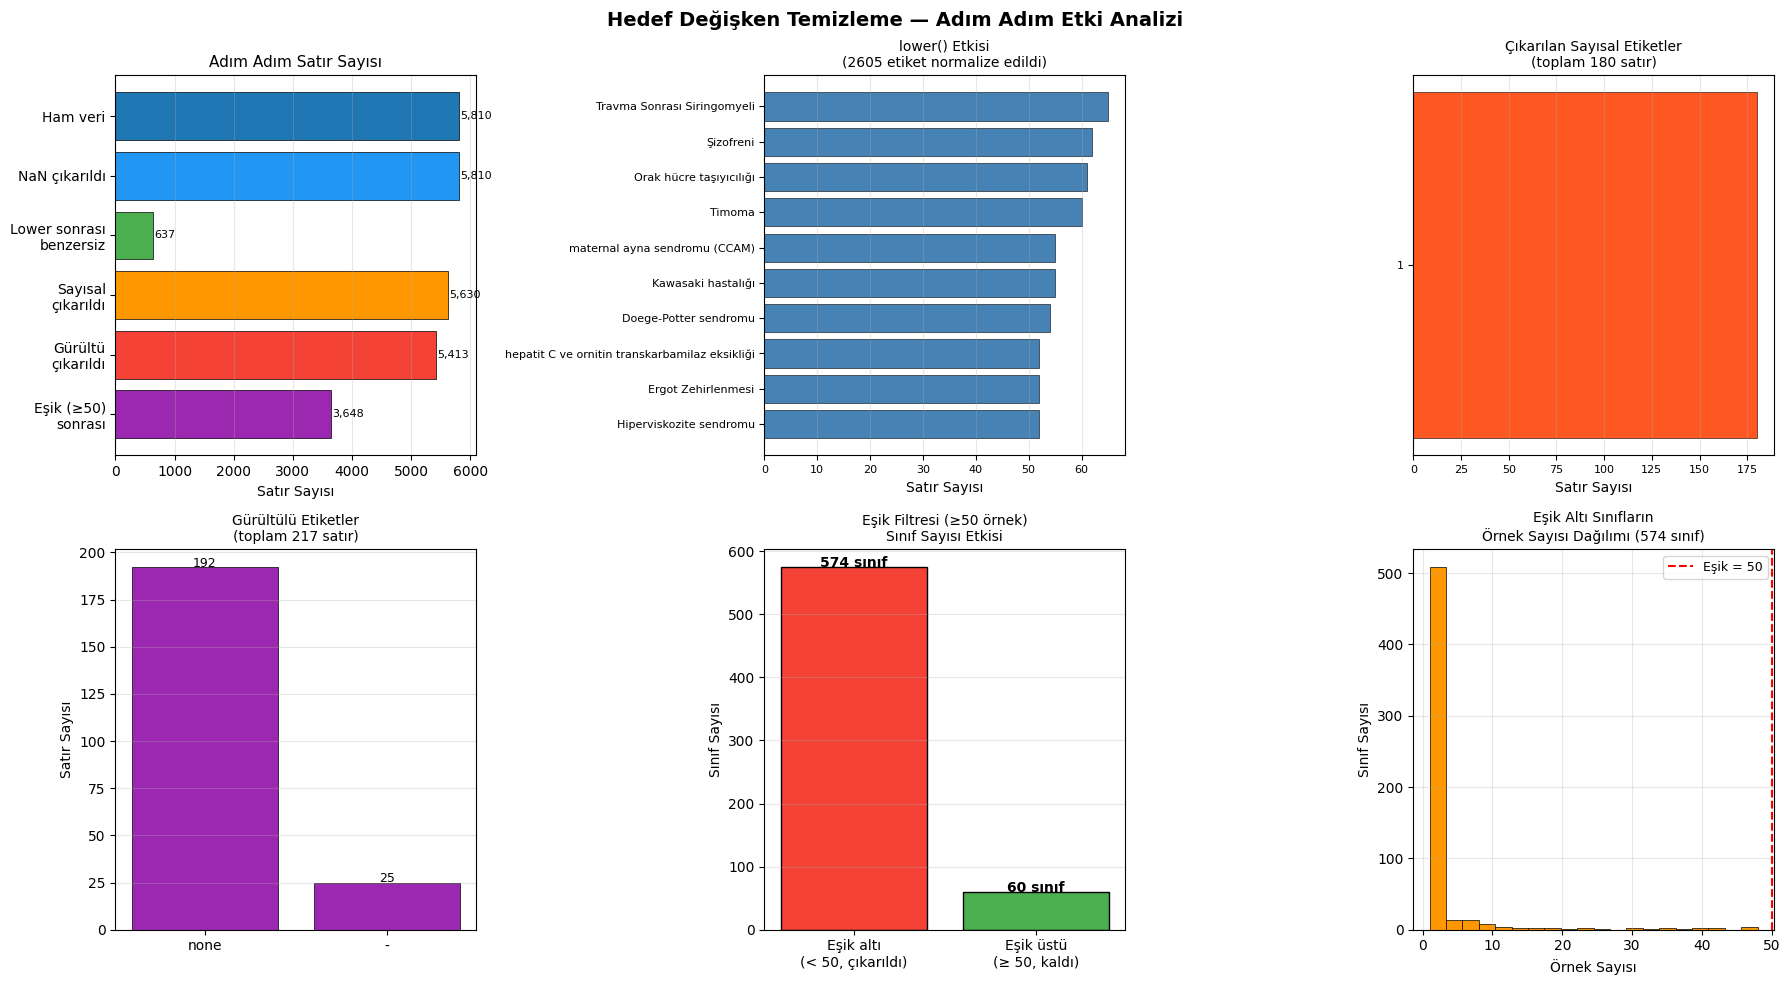

Ham etiket sayısı     : 5,810
Temizlik sonrası satır: 3,648
Kalan sınıf sayısı    : 60


In [33]:
# ─── Hedef Değişken Temizleme — Görselleştirme ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ham = df_ham['correct_prediction'].astype(str).str.strip()   # ham (temizlenmemiş)

# ── 1) lower() etkisi: eşleşen varyantlar ────────────────────────────────────
ham_lower = ham.str.lower()
case_degisen = (ham != ham_lower).sum()
case_ornekler = (ham[ham != ham_lower]
                 .value_counts()
                 .head(10))

# ── 2) Çıkarılan sayısal etiketler ───────────────────────────────────────────
sayi_mask_ham = ham_lower.str.match(r'^\d+$')
sayi_sayim    = ham_lower[sayi_mask_ham].value_counts().head(15)

# ── 3) Gürültülü etiketler ───────────────────────────────────────────────────
GURULTULU = {'', 'none', '-', 'nan'}
gurultulu_mask = ham_lower.isin(GURULTULU) & ~sayi_mask_ham
gurultulu_sayim = ham_lower[gurultulu_mask].replace('', '(boş)').value_counts()

# ── 4) Eşik filtresi (< 50 örnek) ────────────────────────────────────────────
temiz = ham_lower[~sayi_mask_ham & ~ham_lower.isin(GURULTULU)]
sayim_all = temiz.value_counts()
esik_alti = sayim_all[sayim_all < 50]
esik_ustu = sayim_all[sayim_all >= 50]

# ── Görsel ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))

# Sol üst: Huni diyagramı — adım adım satır kaybı
ax1 = fig.add_subplot(2, 3, 1)
adim_isimleri = ['Ham veri', 'NaN çıkarıldı', 'Lower sonrası\nbenzersiz', 'Sayısal\nçıkarıldı', 'Gürültü\nçıkarıldı', f'Eşik (≥50)\nsonrası']
toplam_ham   = len(ham)
nan_cikar    = ham[~ham.isin(['nan','NaN','None',''])].shape[0]   # yaklaşık
lower_unique = ham_lower.nunique()
sayi_cikar   = (~sayi_mask_ham).sum()
gurultulu_cikar = (~sayi_mask_ham & ~ham_lower.isin(GURULTULU)).sum()
esik_son     = esik_ustu.sum()

adim_degerler = [toplam_ham, nan_cikar, lower_unique, sayi_cikar, gurultulu_cikar, esik_son]
renkler_huni = ['#1f77b4','#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']
bars1 = ax1.barh(adim_isimleri[::-1], adim_degerler[::-1],
                 color=renkler_huni[::-1], edgecolor='black', linewidth=0.5)
for bar, v in zip(bars1, adim_degerler[::-1]):
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'{v:,}', va='center', fontsize=8)
ax1.set_title('Adım Adım Satır Sayısı', fontsize=11)
ax1.set_xlabel('Satır Sayısı')
ax1.grid(axis='x', alpha=0.3)

# Orta üst: Lower() ile düzeltilen büyük/küçük harf varyantları
ax2 = fig.add_subplot(2, 3, 2)
if len(case_ornekler) > 0:
    ax2.barh(case_ornekler.index[::-1], case_ornekler.values[::-1],
             color='steelblue', edgecolor='black', linewidth=0.4)
    ax2.set_title(f'lower() Etkisi\n({case_degisen} etiket normalize edildi)', fontsize=10)
    ax2.tick_params(labelsize=8)
    ax2.grid(axis='x', alpha=0.3)
else:
    ax2.text(0.5, 0.5, f'Büyük/küçük harf\nfarkı yok\n(zaten normalize)',
             ha='center', va='center', fontsize=11, transform=ax2.transAxes)
    ax2.set_title('lower() Etkisi', fontsize=11)
ax2.set_xlabel('Satır Sayısı')

# Sağ üst: Çıkarılan sayısal değerler
ax3 = fig.add_subplot(2, 3, 3)
if len(sayi_sayim) > 0:
    ax3.barh(sayi_sayim.index.astype(str)[::-1], sayi_sayim.values[::-1],
             color='#FF5722', edgecolor='black', linewidth=0.4)
    ax3.set_title(f'Çıkarılan Sayısal Etiketler\n(toplam {sayi_mask_ham.sum()} satır)', fontsize=10)
    ax3.set_xlabel('Satır Sayısı')
    ax3.tick_params(labelsize=8)
    ax3.grid(axis='x', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Sayısal etiket yok', ha='center', va='center', fontsize=11)
    ax3.set_title('Çıkarılan Sayısal Etiketler', fontsize=11)

# Sol alt: Gürültülü etiketler (none, nan, -, boş)
ax4 = fig.add_subplot(2, 3, 4)
if len(gurultulu_sayim) > 0:
    ax4.bar(gurultulu_sayim.index.astype(str), gurultulu_sayim.values,
            color='#9C27B0', edgecolor='black', linewidth=0.5)
    for bar, v in zip(ax4.patches, gurultulu_sayim.values):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(v), ha='center', fontsize=9)
    ax4.set_title(f'Gürültülü Etiketler\n(toplam {gurultulu_mask.sum()} satır)', fontsize=10)
    ax4.set_ylabel('Satır Sayısı')
    ax4.grid(axis='y', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Gürültülü etiket yok', ha='center', va='center', fontsize=11)
    ax4.set_title('Gürültülü Etiketler', fontsize=11)

# Orta alt: Eşik altı vs üstü sınıf sayısı
ax5 = fig.add_subplot(2, 3, 5)
kategoriler_esik  = ['Eşik altı\n(< 50, çıkarıldı)', 'Eşik üstü\n(≥ 50, kaldı)']
degerler_esik     = [len(esik_alti), len(esik_ustu)]
renkler_esik      = ['#F44336', '#4CAF50']
bars5 = ax5.bar(kategoriler_esik, degerler_esik, color=renkler_esik, edgecolor='black')
for bar, v in zip(bars5, degerler_esik):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v} sınıf', ha='center', fontsize=10, fontweight='bold')
ax5.set_title('Eşik Filtresi (≥50 örnek)\nSınıf Sayısı Etkisi', fontsize=10)
ax5.set_ylabel('Sınıf Sayısı')
ax5.grid(axis='y', alpha=0.3)

# Sağ alt: Eşik altı kalan sınıfların örnek sayısı dağılımı
ax6 = fig.add_subplot(2, 3, 6)
if len(esik_alti) > 0:
    ax6.hist(esik_alti.values, bins=20, color='#FF9800', edgecolor='black', linewidth=0.5)
    ax6.axvline(50, color='red', ls='--', lw=1.5, label='Eşik = 50')
    ax6.set_title(f'Eşik Altı Sınıfların\nÖrnek Sayısı Dağılımı ({len(esik_alti)} sınıf)', fontsize=10)
    ax6.set_xlabel('Örnek Sayısı')
    ax6.set_ylabel('Sınıf Sayısı')
    ax6.legend(fontsize=9)
    ax6.grid(alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'Eşik altı sınıf yok', ha='center', va='center', fontsize=11)

plt.suptitle('Hedef Değişken Temizleme — Adım Adım Etki Analizi',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/viz_hedef_temizleme.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Ham etiket sayısı     : {toplam_ham:,}')
print(f'Temizlik sonrası satır: {esik_son:,}')
print(f'Kalan sınıf sayısı    : {len(esik_ustu)}')


In [ ]:
#Bağlam Penceresi (Context Window)
# Tek satır çoğunlukla hastalığa özgü bilgi taşımıyor.
# Aynı bölümdeki ±PENCERE komşu satır birleştirilerek model daha
# geniş diyalog bağlamına erişir.


PENCERE = 1  # ±1 satır → toplam 3 satırlık pencere

df = df.sort_values(['season', 'episode']).reset_index(drop=True)
df['text_orijinal'] = df['text'].copy()

def baglamli_metin_olustur(df, pencere):
    bolum_gruplari = df.groupby(['season', 'episode']).indices
    pos_harita = {}
    for pozlar in bolum_gruplari.values():
        sirali = sorted(pozlar)
        for sira, pos in enumerate(sirali):
            pos_harita[pos] = (sira, sirali)

    sonuc = []
    for pos in range(len(df)):
        sira, bolum_pozlar = pos_harita[pos]
        bas = max(0, sira - pencere)
        bit = min(len(bolum_pozlar), sira + pencere + 1)
        metin = ' '.join(
            str(df.at[p, 'text_orijinal'])
            for p in bolum_pozlar[bas:bit]
            if pd.notna(df.at[p, 'text_orijinal'])
        )
        sonuc.append(metin)
    return sonuc

df['text'] = baglamli_metin_olustur(df, PENCERE)

ort_once  = df['text_orijinal'].str.split().str.len().mean()
ort_sonra = df['text'].str.split().str.len().mean()
print(f"Bağlam penceresi ±{PENCERE} satır uygulandı")
print(f"Orijinal ort. kelime sayısı : {ort_once:.0f}")
print(f"Bağlamlı ort. kelime sayısı : {ort_sonra:.0f}")
print(f"\nÖrnek bağlamlı metin (ilk satır):\n{df['text'].iloc[0][:300]}")

# Bağlam öncesi vs sonrası karşılaştırma — ilk 3 örnek
print("=" * 70)
for i in range(3):
    print(f"\n[Satır {i}] Orijinal ({len(str(df['text_orijinal'].iloc[i]).split())} kelime):")
    print(f"  {df['text_orijinal'].iloc[i]}")
    print(f"\n[Satır {i}] Bağlamlı ({len(str(df['text'].iloc[i]).split())} kelime):")
    print(f"  {df['text'].iloc[i]}")
    print("-" * 70)

Bağlam penceresi ±1 satır uygulandı
Orijinal ort. kelime sayısı : 9
Bağlamlı ort. kelime sayısı : 26

Örnek bağlamlı metin (ilk satır):
29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş. Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.

[Satır 0] Orijinal (11 kelime):
  29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş.

[Satır 0] Bağlamlı (19 kelime):
  29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş. Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.
----------------------------------------------------------------------

[Satır 1] Orijinal (8 kelime):
  Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.

[Satır 1] Bağlamlı (23 kelime):
  29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş. Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor. Mental durumu giderek kötüleşiyor.
----------------------------------------------------------------------

[Satır 2] Orijinal (4 kelime):


### Metin Uzunlukları

count    3648.0
mean       26.2
std         9.7
min         6.0
25%        19.0
50%        26.0
75%        33.0
max        84.0
Name: text_len, dtype: float64


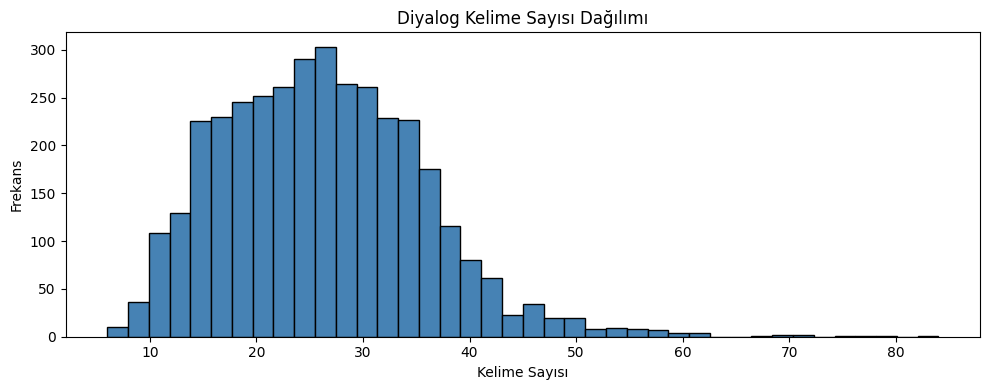

In [35]:
df['text_len'] = df['text'].dropna().str.split().str.len()
print(df['text_len'].describe().round(1))

plt.figure(figsize=(10, 4))
df['text_len'].plot(kind='hist', bins=40, color='steelblue', edgecolor='black')
plt.title('Diyalog Kelime Sayısı Dağılımı')
plt.xlabel('Kelime Sayısı')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

## Adım 3 — Hedef Sütun Temizleme (Top 20 Hastalık)

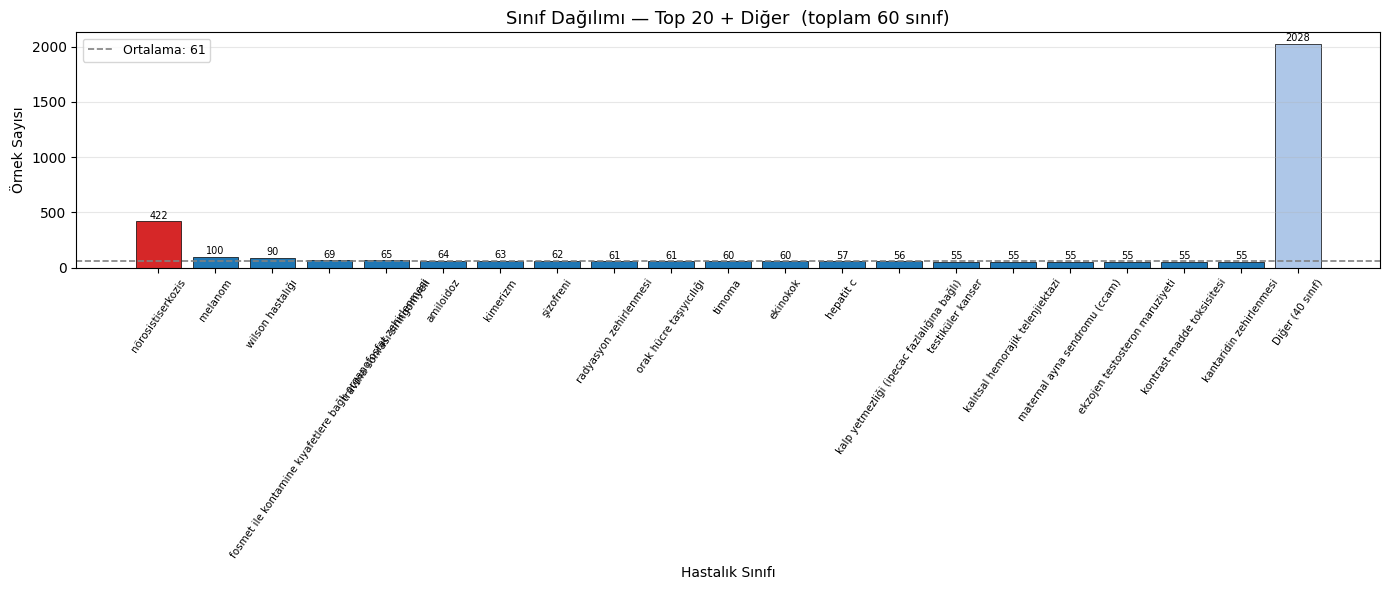

En büyük sınıf  : nörosistiserkozis (422)
En küçük sınıf  : subakut sklerozan panensefalit (50)
Dengesizlik oranı: 8.4x
Top 20 kapsama : %44.4 (toplam 1620 örnek)


In [36]:
sinif_say = df['hedef'].value_counts()
TOP_N = 20

# Top 20 + Diğer
top    = sinif_say.head(TOP_N)
diger  = sinif_say.iloc[TOP_N:].sum()
diger_n = len(sinif_say) - TOP_N

goster = list(top.items()) + [(f'Diğer ({diger_n} sınıf)', diger)]
isimler = [g[0] for g in goster]
degerler = [g[1] for g in goster]

renkler = (['#d62728']           # 1. sınıf (dominant)
           + ['#1f77b4'] * (TOP_N - 1)  # top 20
           + ['#aec7e8'])        # Diğer (soluk mavi)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(isimler, degerler, color=renkler, edgecolor='black', linewidth=0.5)

# Değer etiketleri
for bar, v in zip(bars, degerler):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(v), ha='center', va='bottom', fontsize=7)

ax.axhline(sinif_say.mean(), color='grey', ls='--', lw=1.2,
           label=f'Ortalama: {sinif_say.mean():.0f}')
ax.set_title(f'Sınıf Dağılımı — Top {TOP_N} + Diğer  (toplam {len(sinif_say)} sınıf)',
             fontsize=13)
ax.set_xlabel('Hastalık Sınıfı')
ax.set_ylabel('Örnek Sayısı')
ax.tick_params(axis='x', rotation=55, labelsize=7.5)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/sinif_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'En büyük sınıf  : {sinif_say.idxmax()} ({sinif_say.max()})')
print(f'En küçük sınıf  : {sinif_say.idxmin()} ({sinif_say.min()})')
print(f'Dengesizlik oranı: {sinif_say.max()/sinif_say.min():.1f}x')
print(f'Top {TOP_N} kapsama : %{top.sum()/sinif_say.sum()*100:.1f} (toplam {top.sum()} örnek)')


## Adım 4 — Özellik Mühendisliği

### 4a — Metin Ön İşleme + TF-IDF

Uyguladığımız adımlar:

| # | Adım | Ne yapıyor? |
|---|------|-------------|
| 1 | **Temizleme** | HTML etiketleri ve özel karakterler kaldırılır; **sayılar korunur** (yaş, dozaj, süre medikal bilgi taşır) |
| 2 | **Tokenization** | Cümle boşluklardan kelime listesine bölünür |
| 3 | **Stop-words** | Düşük bilgili kelimeler atılır; **"önce", "sonra", "var", "yok" listede YOK** — zaman ve varlık/yokluk bilgisi tıbbi teşhiste kritik |
| 4 | **Lowercasing** | Tüm metin küçük harfe çevrilir |
| 5 | **Bigram** | TF-IDF'te `ngram_range=(1,2)` ile "nöbet geçir", "ay önce" gibi kelime çiftleri özellik olarak eklenir |

> **Not:** Stemming uygulanmıyor — Snowball Türkçe stemmer tıbbi kelimelerde anlam bozuyor (`kadın→kadı`, `hasta→has`).

In [37]:
import snowballstemmer

# ── Stop-words — Türkçe (Medikal NLP için özelleştirilmiş) ───────────────────
# "önce", "sonra": zaman belirteci — akut/kronik ayrımı için kritik
# "var", "yok"  : varlık/yokluk bilgisi — tıbbi teşhiste ayırt edici
TURKCE_STOPWORDS = {
    'bir', 've', 'bu', 'da', 'de', 'ile', 'için', 'mi', 'mu', 'mı', 'mü',
    'ki', 'ne', 'o', 'ben', 'sen', 'biz', 'siz', 'onlar',
    'ama', 'fakat', 'lakin', 'ancak', 'ya', 'veya', 'yahut', 'hem',
    'çünkü', 'eğer', 'ise', 'gibi', 'kadar', 'daha', 'en',
    'her', 'bazı', 'tüm', 'bütün', 'hangi', 'nasıl', 'neden', 'niçin',
    'şu', 'şey', 'olan', 'olarak', 'üzere', 'göre', 'karşı',
    'yani', 'sadece', 'bile', 'dahi', 'hatta', 'artık', 'zaten',
    'peki', 'evet', 'hayır', 'tamam', 'diye', 'bunu',
    'buna', 'bunun', 'şunu', 'şuna', 'onun', 'beni', 'seni', 'onu',
    'bizi', 'sizi', 'onları', 'bende', 'sende', 'onda',
}

def on_isle(metin):
    """Lowercasing + HTML / özel karakter temizleme. Sayılar KORUNUR."""
    metin = str(metin).lower()
    metin = re.sub(r'<[^>]+>', ' ', metin)
    metin = re.sub(r'[^\w\s]', ' ', metin)
    return re.sub(r'\s+', ' ', metin).strip()

def on_isle_tam(metin):
    """Temizleme → tokenization → stop-words.
    Stemming uygulanmıyor: Snowball Türkçe stemmer tıbbi kelimelerde
    anlam bozuyor (örn. kadın→kadı, hasta→has)."""
    metin = on_isle(metin)
    tokens = metin.split()
    tokens = [t for t in tokens
              if t not in TURKCE_STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

def isle_ve_etiketle(row):
    metin = on_isle_tam(row['text'])
    if str(row['Sarcasm']).strip() == '1':
        # Alaycı cümlelerde her kelimeye "ALAY_" eki ekleniyor.
        # Böylece "tümör" (gerçek teşhis) ile "ALAY_tümör" (alaycı bağlam)
        # model için tamamen ayrı özellikler olur; gerçek tıbbi terimlerin
        # ağırlığı bozulmaz.
        metin = ' '.join('ALAY_' + t for t in metin.split())
    return metin

df['text_clean'] = df.apply(isle_ve_etiketle, axis=1)

# Alaycı olmayan cümlelere 1.0, alaycılara 0.3 ağırlık atanıyor.
# Model alaycı satırlardan öğrenmeyi sürdürür ama bu satırların
# tahmin üzerindeki etkisi ~3 kat azaltılır.
SARCASM_WEIGHT = 0.3
df['sample_weight'] = df['Sarcasm'].apply(
    lambda x: SARCASM_WEIGHT if str(x).strip() == '1' else 1.0
)

sarcasm_n = (df['Sarcasm'].astype(str).str.strip() == '1').sum()
print(f'Alaycı: {sarcasm_n} (ağırlık={SARCASM_WEIGHT}) — Normal: {len(df) - sarcasm_n} (ağırlık=1.0)')

# Örnek: ALAY_ prefix kontrolü
ornek_alay = df[df['Sarcasm'].astype(str).str.strip() == '1']['text_clean'].iloc[0]
print(f'\nAlaycı örnek: {ornek_alay[:120]}')

TIBBI = ['Symptom', 'Test', 'Drug', 'Procedure', 'Organ']
df['tibbi_metin'] = df[TIBBI].fillna('bilgi_yok').apply(
    lambda row: ' '.join(row.values.astype(str)), axis=1
).apply(on_isle_tam)

# ── Vectorizer'lar ────────────────────────────────────────────────────────────
tfidf_text  = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_tibbi = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

X_text  = tfidf_text.fit_transform(df['text_clean'])
X_tibbi = tfidf_tibbi.fit_transform(df['tibbi_metin'])

print('\nX_text  :', X_text.shape)
print('X_tibbi :', X_tibbi.shape)

Alaycı: 166 (ağırlık=0.3) — Normal: 3482 (ağırlık=1.0)

Alaycı örnek: ALAY_mental ALAY_durumu ALAY_giderek ALAY_kötüleşiyor ALAY_beyin ALAY_tümörü ALAY_dediler ALAY_olsam ALAY_tanıyı ALAY_se

X_text  : (3648, 5000)
X_tibbi : (3648, 3000)


### 4b — Kategorik (One-Hot)

In [38]:
KATEGORIK = ['Intent', 'diagnosis_stage', 'Emotion', 'speaker']
df_kat = df[KATEGORIK].fillna('bilinmiyor').astype(str)
for col in KATEGORIK:
    nadir = df_kat[col].value_counts()
    df_kat[col] = df_kat[col].replace(nadir[nadir < 5].index, 'diger')

kat_dummies = pd.get_dummies(df_kat, drop_first=True).astype(float)
KAT_KOLONLAR = kat_dummies.columns.tolist()  # canlı test için kolon sırası kaydediliyor

X_kat_sparse = csr_matrix(kat_dummies.values)
print('X_kategorik :', X_kat_sparse.shape)
print('Kolon sayısı :', len(KAT_KOLONLAR))

X_kategorik : (3648, 151)
Kolon sayısı : 151


### 4c — JSON Çözümleme: medical_entities

In [39]:
# Disease / Diagnosis tipleri çıkarıldı — doğrudan hedef etiketini sızdırıyordu (data leakage)
TYPE_MAP = {
    'Symptom': 'ent_Symptom', 'SYMP': 'ent_Symptom',
    'Test': 'ent_Test', 'TEST': 'ent_Test', 'Test Sonucu': 'ent_Test',
    'Drug': 'ent_Drug', 'DRUG': 'ent_Drug', 'Medication': 'ent_Drug',
    'Procedure': 'ent_Procedure', 'PROC': 'ent_Procedure', 'Treatment': 'ent_Procedure',
    'Anatomy': 'ent_Anatomy', 'Organ': 'ent_Anatomy', 'ORG': 'ent_Anatomy',
}
ENT_COLS = ['ent_Symptom', 'ent_Test', 'ent_Drug', 'ent_Procedure', 'ent_Anatomy']

def parse_entities(json_str):
    sonuc = {col: [] for col in ENT_COLS}
    try:
        for e in json.loads(str(json_str)):
            if not isinstance(e, dict):
                continue
            tip = TYPE_MAP.get(e.get('type', ''))
            if tip:
                sonuc[tip].append(str(e.get('text', '')).lower())
    except Exception:
        pass
    return {col: ' '.join(v) for col, v in sonuc.items()}

ent_df = df['medical_entities'].fillna('[]').apply(parse_entities).apply(pd.Series)
df = pd.concat([df, ent_df], axis=1)

df['ent_all'] = df[ENT_COLS].fillna('').apply(
    lambda row: ' '.join(row.values.astype(str)), axis=1
).apply(on_isle)

tfidf_entity = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_entity = tfidf_entity.fit_transform(df['ent_all'])
print('X_entity :', X_entity.shape)

X_entity : (3648, 3000)


### 4c-2 — Entity Sayıları (Sayısal Özellikler)

Her satır için kaç adet semptom, ilaç, test, prosedür ve anatomi entity'si geçtiği sayılır.  
*(Hastalık adı içeren entity'ler data leakage yarattığı için çıkarıldı.)*

In [40]:
def count_entities(json_str):
    counts = {col: 0 for col in ENT_COLS}
    try:
        for e in json.loads(str(json_str)):
            if not isinstance(e, dict):
                continue
            tip = TYPE_MAP.get(e.get('type', ''))
            if tip:
                counts[tip] += 1
    except Exception:
        pass
    return counts

ENT_COUNT_COLS = [col.replace('ent_', 'n_') for col in ENT_COLS]

ent_counts = (
    df['medical_entities']
    .fillna('[]')
    .apply(count_entities)
    .apply(pd.Series)
    .rename(columns=dict(zip(ENT_COLS, ENT_COUNT_COLS)))
)
ent_counts['n_total'] = ent_counts.sum(axis=1)

df = pd.concat([df, ent_counts], axis=1)

X_ent_counts = csr_matrix(ent_counts.values.astype(float))

print('Oluşturulan sayısal sütunlar:', ent_counts.columns.tolist())
print('X_ent_counts :', X_ent_counts.shape)
print()
print(ent_counts.describe().round(2))

Oluşturulan sayısal sütunlar: ['n_Symptom', 'n_Test', 'n_Drug', 'n_Procedure', 'n_Anatomy', 'n_total']
X_ent_counts : (3648, 6)

       n_Symptom   n_Test   n_Drug  n_Procedure  n_Anatomy  n_total
count    3648.00  3648.00  3648.00      3648.00    3648.00  3648.00
mean        0.43     0.24     0.17         0.12       0.24     1.20
std         0.71     0.52     0.46         0.36       0.53     1.06
min         0.00     0.00     0.00         0.00       0.00     0.00
25%         0.00     0.00     0.00         0.00       0.00     0.00
50%         0.00     0.00     0.00         0.00       0.00     1.00
75%         1.00     0.00     0.00         0.00       0.00     2.00
max         7.00     5.00     4.00         4.00       5.00     7.00


## Adım 5 — Özellik Birleştirme

In [41]:
SAYISAL = ['Sarcasm', 'season', 'episode']

X_say = csr_matrix(
    df[SAYISAL].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float).values
)

X = hstack([X_text, X_tibbi, X_entity, X_kat_sparse, X_say, X_ent_counts])
y = df['hedef']

print('Özellik grupları:')
print(f'  X_text       : {X_text.shape}')
print(f'  X_tibbi      : {X_tibbi.shape}')
print(f'  X_entity     : {X_entity.shape}')
print(f'  X_kategorik  : {X_kat_sparse.shape}')
print(f'  X_sayisal    : {X_say.shape}')
print(f'  X_ent_counts : {X_ent_counts.shape}')
print(f'  ─────────────────────')
print(f'  TOPLAM       : {X.shape}')

Özellik grupları:
  X_text       : (3648, 5000)
  X_tibbi      : (3648, 3000)
  X_entity     : (3648, 3000)
  X_kategorik  : (3648, 151)
  X_sayisal    : (3648, 3)
  X_ent_counts : (3648, 6)
  ─────────────────────
  TOPLAM       : (3648, 11160)


## Adım 6 — Train / Test Bölme

In [42]:
# stratify=y — Tabakalı bölme (Stratified Split)
# Veri setinde nörosistiserkozis 422 satır (%26), en küçük sınıflar ise 55 satır.
# Rastgele bölmede test setine bazı hastalıklardan hiç örnek düşmeyebilir.
# stratify=y, eğitim ve test setinin sınıf dağılım oranını korur;
# böylece her hastalık her iki sette de orantılı temsil edilir.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Eğitim seti:', X_train.shape)
print('Test seti  :', X_test.shape)

Eğitim seti: (2918, 11160)
Test seti  : (730, 11160)


## Adım 6b — Oversampling (Devre Dışı)

Oversampling (SMOTE / RandomOverSampler) TF-IDF vektörlerinde anlamlı iyileşme sağlamadı.  
Temel sorun örnek sayısı değil **semantik örtüşme** olduğundan, doğrudan **threshold tuning** uygulanıyor.  
Bu hücre çalıştırılmadan atlanabilir — eğitim adımları orijinal `X_train / y_train` üzerinden devam eder.

In [43]:
# Oversampling atlandı — orijinal eğitim verisi kullanılıyor
X_train_sm  = X_train
y_train_sm  = y_train
sw_train    = df.loc[y_train.index, 'sample_weight'].values
sw_train_sm = sw_train
print("Oversampling atlandı. Eğitim seti:", X_train_sm.shape)

Oversampling atlandı. Eğitim seti: (2918, 11160)


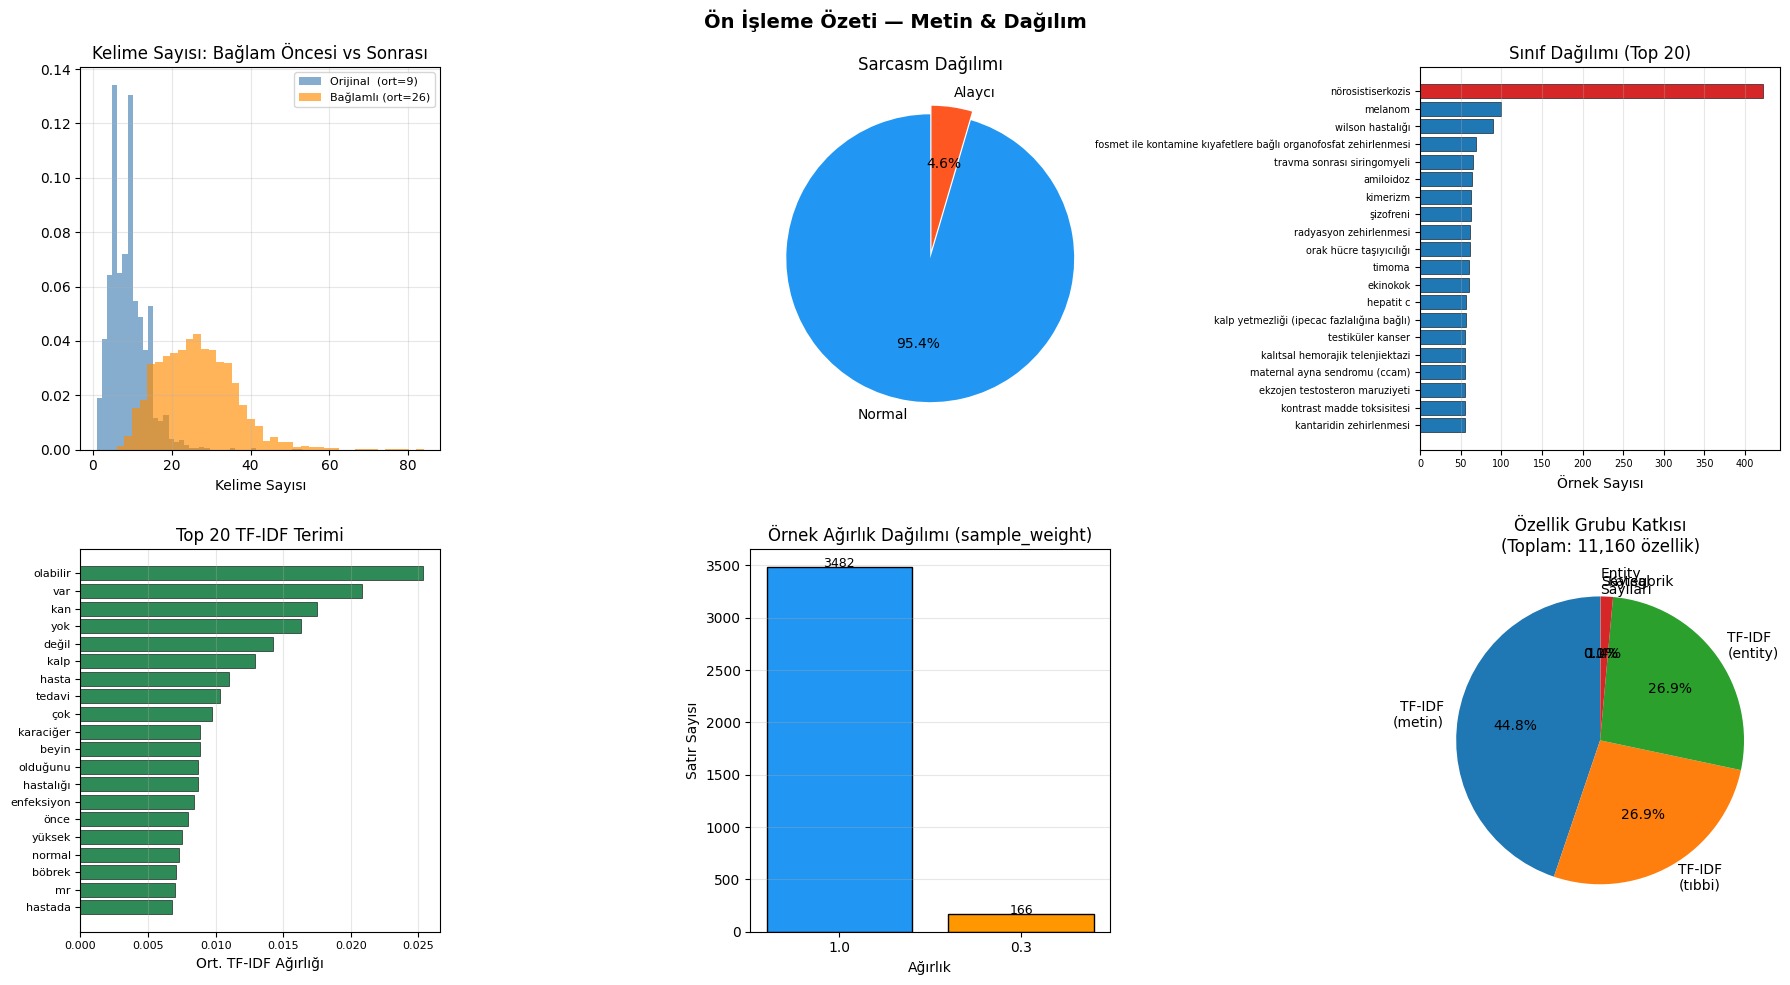

In [44]:
# ─── VİZÜEL ÖZET 1: Metin & Sarcasm ─────────────────────────────────────
fig = plt.figure(figsize=(18, 10))

# 1) Kelime sayısı: bağlam öncesi vs sonrası
ax1 = fig.add_subplot(2, 3, 1)
len_once  = df['text_orijinal'].str.split().str.len().dropna()
len_sonra = df['text'].str.split().str.len().dropna()
ax1.hist(len_once,  bins=40, alpha=0.65, label=f'Orijinal  (ort={len_once.mean():.0f})',
         color='steelblue', density=True)
ax1.hist(len_sonra, bins=40, alpha=0.65, label=f'Bağlamlı (ort={len_sonra.mean():.0f})',
         color='darkorange', density=True)
ax1.set_title('Kelime Sayısı: Bağlam Öncesi vs Sonrası')
ax1.set_xlabel('Kelime Sayısı')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# 2) Sarcasm dağılımı
ax2 = fig.add_subplot(2, 3, 2)
sc = df['Sarcasm'].astype(str).str.strip().map({'0': 'Normal', '1': 'Alaycı'}).value_counts()
ax2.pie(sc, labels=sc.index, autopct='%1.1f%%',
        colors=['#2196F3', '#FF5722'], startangle=90, explode=[0, 0.06])
ax2.set_title('Sarcasm Dağılımı')

# 3) Sınıf dağılımı — yatay çubuk (top 20)
ax3 = fig.add_subplot(2, 3, 3)
top20 = df['hedef'].value_counts().head(20)
renkler_top = ['#d62728' if i == 0 else '#1f77b4' for i in range(len(top20))]
ax3.barh(top20.index[::-1], top20.values[::-1],
         color=renkler_top[::-1], edgecolor='black', linewidth=0.4)
ax3.set_title('Sınıf Dağılımı (Top 20)')
ax3.set_xlabel('Örnek Sayısı')
ax3.tick_params(labelsize=7)
ax3.grid(axis='x', alpha=0.3)

# 4) Top 20 TF-IDF terimi
ax4 = fig.add_subplot(2, 3, 4)
feat_names = np.array(tfidf_text.get_feature_names_out())
mean_tfidf = np.asarray(X_text.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-20:]
ax4.barh(feat_names[top_idx], mean_tfidf[top_idx],
         color='seagreen', edgecolor='black', linewidth=0.4)
ax4.set_title('Top 20 TF-IDF Terimi')
ax4.set_xlabel('Ort. TF-IDF Ağırlığı')
ax4.tick_params(labelsize=8)
ax4.grid(axis='x', alpha=0.3)

# 5) Örnek ağırlıkları
ax5 = fig.add_subplot(2, 3, 5)
sw = df['sample_weight'].value_counts()
bars5 = ax5.bar([str(k) for k in sw.index], sw.values,
                color=['#2196F3', '#FF9800'], edgecolor='black')
for bar, v in zip(bars5, sw.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(v), ha='center', fontsize=9)
ax5.set_title('Örnek Ağırlık Dağılımı (sample_weight)')
ax5.set_xlabel('Ağırlık')
ax5.set_ylabel('Satır Sayısı')
ax5.grid(axis='y', alpha=0.3)

# 6) Özellik grubu katkısı
ax6 = fig.add_subplot(2, 3, 6)
grup_isimleri = ['TF-IDF\n(metin)', 'TF-IDF\n(tıbbi)', 'TF-IDF\n(entity)',
                 'Kategorik', 'Sayısal', 'Entity\nSayıları']
grup_boyut = [X_text.shape[1], X_tibbi.shape[1], X_entity.shape[1],
              X_kat_sparse.shape[1], X_say.shape[1], X_ent_counts.shape[1]]
ax6.pie(grup_boyut, labels=grup_isimleri, autopct='%1.1f%%', startangle=90,
        colors=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'])
ax6.set_title(f'Özellik Grubu Katkısı\n(Toplam: {sum(grup_boyut):,} özellik)')

plt.suptitle('Ön İşleme Özeti — Metin & Dağılım', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/viz_metin_sarcasm.png', dpi=150, bbox_inches='tight')
plt.show()


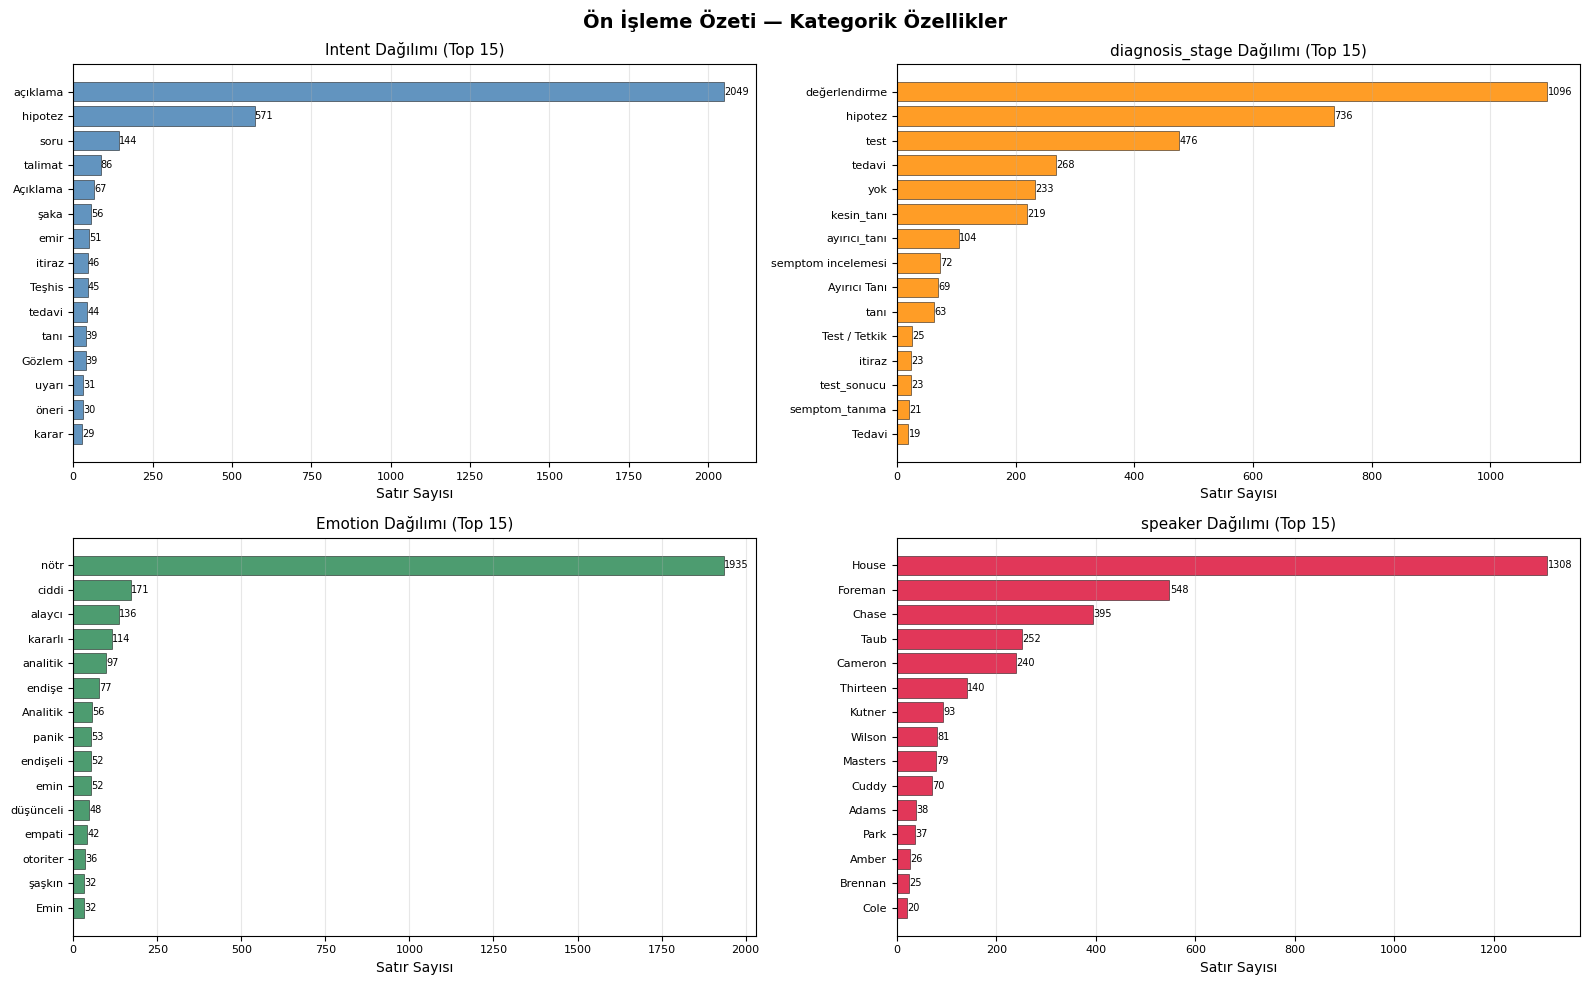

In [45]:
# ─── VİZÜEL ÖZET 2: Kategorik Özellikler ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

kategoriler  = ['Intent', 'diagnosis_stage', 'Emotion', 'speaker']
renk_listesi = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for ax, kol, renk in zip(axes.flatten(), kategoriler, renk_listesi):
    vals = df[kol].fillna('bilinmiyor').value_counts().head(15)
    ax.barh(vals.index[::-1], vals.values[::-1],
            color=renk, edgecolor='black', linewidth=0.4, alpha=0.85)
    ax.set_title(f'{kol} Dağılımı (Top 15)', fontsize=11)
    ax.set_xlabel('Satır Sayısı')
    ax.tick_params(labelsize=8)
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(ax.patches, vals.values[::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(v), va='center', fontsize=7)

plt.suptitle('Ön İşleme Özeti — Kategorik Özellikler', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/viz_kategorik.png', dpi=150, bbox_inches='tight')
plt.show()


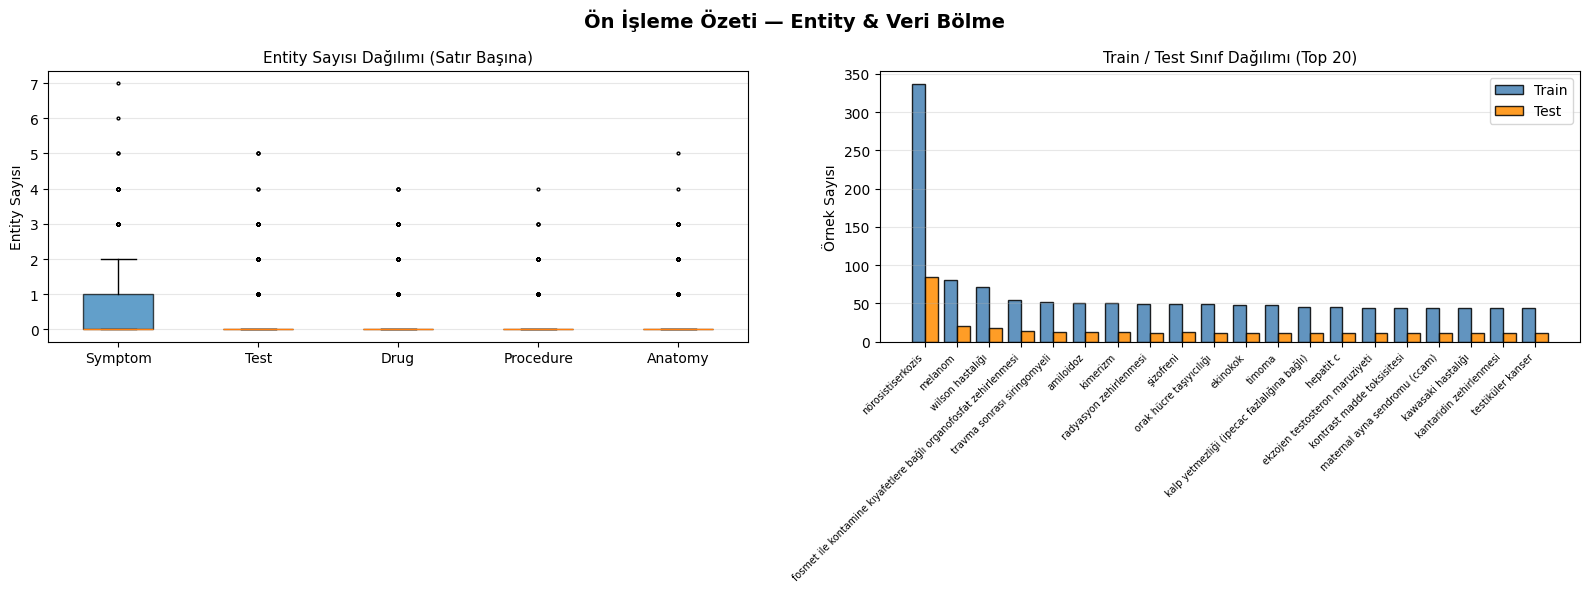

In [46]:
# ─── VİZÜEL ÖZET 3: Entity Sayıları & Train/Test Dengesi ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Entity sayıları — box plot
ax1 = axes[0]
ent_data   = [ent_counts[col].values for col in ENT_COUNT_COLS]
ent_labels = [c.replace('n_', '') for c in ENT_COUNT_COLS]
bp = ax1.boxplot(ent_data, labels=ent_labels, patch_artist=True,
                 showfliers=True, flierprops=dict(markersize=2))
renk_box = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
for patch, renk in zip(bp['boxes'], renk_box):
    patch.set_facecolor(renk)
    patch.set_alpha(0.7)
ax1.set_title('Entity Sayısı Dağılımı (Satır Başına)', fontsize=11)
ax1.set_ylabel('Entity Sayısı')
ax1.grid(axis='y', alpha=0.3)

# Train / Test sınıf dağılımı (top 20)
ax2 = axes[1]
train_dist = y_train.value_counts().head(20)
test_dist  = y_test.value_counts().reindex(train_dist.index).fillna(0)
xi = np.arange(len(train_dist))
w  = 0.4
ax2.bar(xi - w/2, train_dist.values, w, label='Train',
        color='steelblue', alpha=0.85, edgecolor='black')
ax2.bar(xi + w/2, test_dist.values,  w, label='Test',
        color='darkorange', alpha=0.85, edgecolor='black')
ax2.set_xticks(xi)
ax2.set_xticklabels(train_dist.index, rotation=45, ha='right', fontsize=7)
ax2.set_title('Train / Test Sınıf Dağılımı (Top 20)', fontsize=11)
ax2.set_ylabel('Örnek Sayısı')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Ön İşleme Özeti — Entity & Veri Bölme', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/viz_entity_split.png', dpi=150, bbox_inches='tight')
plt.show()


## Adım 7 — Model Eğitimi

In [47]:
from sklearn.model_selection import cross_val_score

modeller = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced',
        C=1.0
    ),
    'LinearSVC': LinearSVC(
        max_iter=2000, random_state=42,
        class_weight='balanced',
        C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1,
        class_weight='balanced'
    ),
}

sonuclar = {}
cv_sonuclar = {}

for isim, model in modeller.items():
    # CV: SMOTE'lu eğitim seti üzerinde (test sete dokunulmaz)
    cv_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='f1_macro', n_jobs=-1)
    cv_sonuclar[isim] = cv_scores

    # Final fit: SMOTE'lu veri + sample_weight
    model.fit(X_train_sm, y_train_sm, sample_weight=sw_train_sm)
    y_pred = model.predict(X_test)
    sonuclar[isim] = y_pred

    acc = (y_pred == y_test).mean()
    print(f'{isim:<25}  Test Acc: {acc:.4f}  |  CV F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Logistic Regression        Test Acc: 0.8205  |  CV F1-macro: 0.7964 ± 0.0134
LinearSVC                  Test Acc: 0.9452  |  CV F1-macro: 0.9000 ± 0.0119
Random Forest              Test Acc: 0.8438  |  CV F1-macro: 0.8085 ± 0.0228


### Adım 7b — Hiperparametre Optimizasyonu (LR) + LightGBM

- **GridSearchCV**: Logistic Regression için en iyi `C` değeri 5-fold CV ile aranır.  
- **LightGBM**: Hataları sırayla öğrenen gradient boosting modeli; kategorik ve sayısal özellikleri TF-IDF ile birlikte dengeli işler.

In [48]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

# ── 1. Logistic Regression — C parametresi tuning ────────────────────────────
print('GridSearchCV çalışıyor (LR)...')
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
)
gs_lr.fit(X_train_sm, y_train_sm, sample_weight=sw_train_sm)

best_lr        = gs_lr.best_estimator_
y_pred_lr_best = best_lr.predict(X_test)
acc_lr_best    = (y_pred_lr_best == y_test).mean()
cv_lr_best     = cross_val_score(best_lr, X_train_sm, y_train_sm, cv=5, scoring='f1_macro', n_jobs=-1)

print(f'Tuned LR  →  En iyi C : {gs_lr.best_params_["C"]}')
print(f'           CV F1-macro : {cv_lr_best.mean():.4f} ± {cv_lr_best.std():.4f}')
print(f'           Test Acc    : {acc_lr_best:.4f}')

# ── 2. LightGBM ───────────────────────────────────────────────────────────────
print('\nLightGBM eğitiliyor...')
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(X_train_sm, y_train_sm, sample_weight=sw_train_sm)

y_pred_lgbm = lgbm.predict(X_test)
acc_lgbm    = (y_pred_lgbm == y_test).mean()
cv_lgbm     = cross_val_score(lgbm, X_train_sm, y_train_sm, cv=5, scoring='f1_macro', n_jobs=-1)

print(f'LightGBM  →  Test Acc    : {acc_lgbm:.4f}')
print(f'             CV F1-macro : {cv_lgbm.mean():.4f} ± {cv_lgbm.std():.4f}')

# ── Karşılaştırma tablosuna ekle ──────────────────────────────────────────────
sonuclar['Tuned LR']    = y_pred_lr_best
sonuclar['LightGBM']    = y_pred_lgbm
cv_sonuclar['Tuned LR'] = cv_lr_best
cv_sonuclar['LightGBM'] = cv_lgbm
modeller['Tuned LR']    = best_lr
modeller['LightGBM']    = lgbm

print('\n{:<30} {:>10} {:>14}'.format('Model', 'Test Acc', 'CV F1-macro'))
print('-' * 56)
for isim in modeller:
    pred = sonuclar[isim]
    acc  = (pred == y_test).mean()
    f1   = cv_sonuclar[isim].mean()
    print(f'{isim:<30} {acc:>10.4f} {f1:>14.4f}')

GridSearchCV çalışıyor (LR)...
Tuned LR  →  En iyi C : 100
           CV F1-macro : 0.8636 ± 0.0133
           Test Acc    : 0.9123

LightGBM eğitiliyor...
LightGBM  →  Test Acc    : 0.9945
             CV F1-macro : 0.9958 ± 0.0014

Model                            Test Acc    CV F1-macro
--------------------------------------------------------
Logistic Regression                0.8205         0.7964
LinearSVC                          0.9452         0.9000
Random Forest                      0.8438         0.8085
Tuned LR                           0.9123         0.8636
LightGBM                           0.9945         0.9958


          Accuracy  Macro F1  Macro Pre  Macro Rec
Model                                             
LR  C=1     0.9123    0.9137     0.9176     0.9168
LR C=100    0.8205    0.8404     0.8377     0.8627


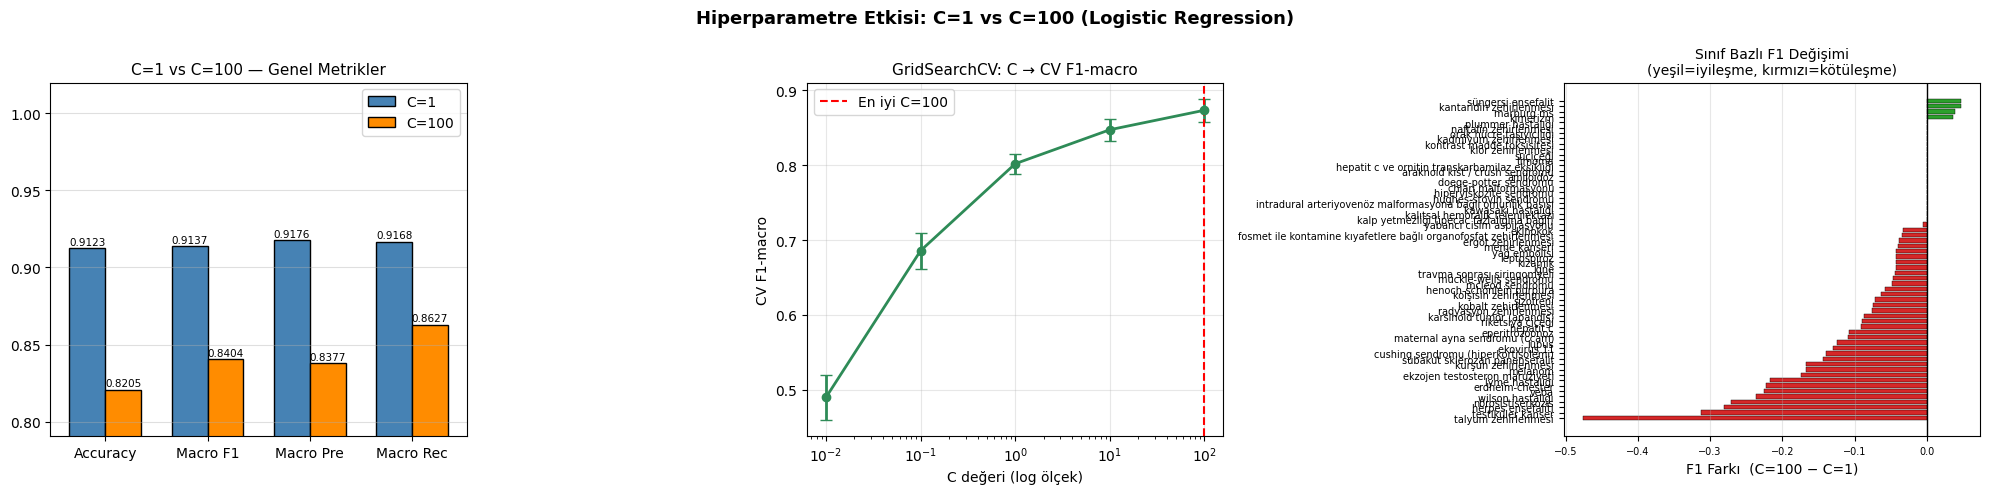

In [49]:
# ─── C=1 vs C=100 Karşılaştırması ────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# C=1 modelini eğit (varsayılan hiperparametre)
lr_c1 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=100)
lr_c1.fit(X_train_sm, y_train_sm, sample_weight=sw_train_sm)
y_pred_c1   = lr_c1.predict(X_test)
y_pred_c100 = sonuclar['Logistic Regression']   # code-train'de C=100 ile eğitildi

def ozet_metrik(y_true, y_pred, isim):
    return {
        'Model':     isim,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Macro F1':  f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Pre': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Rec': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

df_cmp = pd.DataFrame([
    ozet_metrik(y_test, y_pred_c1,   'LR  C=1'),
    ozet_metrik(y_test, y_pred_c100, 'LR C=100'),
]).set_index('Model')
print(df_cmp.round(4).to_string())

metriks = ['Accuracy', 'Macro F1', 'Macro Pre', 'Macro Rec']
x = np.arange(len(metriks))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Görsel 1: Genel metrik karşılaştırması
ax = axes[0]
bars1 = ax.bar(x - w/2, df_cmp.loc['LR  C=1',  metriks], w,
               label='C=1', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + w/2, df_cmp.loc['LR C=100', metriks], w,
               label='C=100', color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metriks)
y_min = float(df_cmp[metriks].min().min()) - 0.03
ax.set_ylim(max(0, y_min), 1.02)
ax.set_title('C=1 vs C=100 — Genel Metrikler', fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.4)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)

# Görsel 2: GridSearchCV — C vs CV F1-macro
ax2 = axes[1]
cv_res   = pd.DataFrame(gs_lr.cv_results_)
c_vals   = cv_res['param_C'].astype(float)
mean_f1  = cv_res['mean_test_score']
std_f1   = cv_res['std_test_score']
ax2.errorbar(c_vals, mean_f1, yerr=std_f1, marker='o',
             color='seagreen', capsize=4, linewidth=2, markersize=6)
ax2.set_xscale('log')
ax2.set_xlabel('C değeri (log ölçek)')
ax2.set_ylabel('CV F1-macro')
ax2.set_title('GridSearchCV: C → CV F1-macro', fontsize=11)
best_c = gs_lr.best_params_['C']
ax2.axvline(best_c, color='red', ls='--', lw=1.5, label=f'En iyi C={best_c}')
ax2.legend()
ax2.grid(alpha=0.3)

# Görsel 3: Sınıf bazlı F1 farkı (C=100 − C=1)
ax3 = axes[2]
r1 = pd.DataFrame(classification_report(y_test, y_pred_c1,
                  output_dict=True, zero_division=0)).T
r2 = pd.DataFrame(classification_report(y_test, y_pred_c100,
                  output_dict=True, zero_division=0)).T
idx_sinif = [c for c in r1.index if c not in ['accuracy', 'macro avg', 'weighted avg']]
diff = (r2.loc[idx_sinif, 'f1-score'] - r1.loc[idx_sinif, 'f1-score']).sort_values()
renkler_diff = ['#d62728' if v < 0 else '#2ca02c' for v in diff]
ax3.barh(diff.index, diff.values, color=renkler_diff, edgecolor='black', linewidth=0.3)
ax3.axvline(0, color='black', lw=1)
ax3.set_xlabel('F1 Farkı  (C=100 − C=1)')
ax3.set_title('Sınıf Bazlı F1 Değişimi\n(yeşil=iyileşme, kırmızı=kötüleşme)', fontsize=10)
ax3.tick_params(labelsize=7)
ax3.grid(axis='x', alpha=0.3)

plt.suptitle('Hiperparametre Etkisi: C=1 vs C=100 (Logistic Regression)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/c1_vs_c100.png', dpi=150, bbox_inches='tight')
plt.show()


## Adım 8 — Değerlendirme

In [52]:
en_iyi = 'LinearSVC'
print(f'=== {en_iyi} — Classification Report ===')
print(classification_report(y_test, sonuclar[en_iyi]))

=== LinearSVC — Classification Report ===
                                                                  precision    recall  f1-score   support

                                                       amiloidoz       1.00      0.85      0.92        13
                                  araknoid kist / crush sendromu       1.00      0.90      0.95        10
                                            chiari malformasyonu       0.89      0.80      0.84        10
                             cushing sendromu (hiperkortisolemi)       1.00      0.90      0.95        10
                                           doege-potter sendromu       0.91      0.91      0.91        11
                                                        ekinokok       0.92      0.92      0.92        12
                                                     ekovirus 11       1.00      1.00      1.00        10
                                  ekzojen testosteron maruziyeti       1.00      0.91      0.95        11
   

                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.8205     0.8377  0.8627  0.8404
LinearSVC              0.9452     0.9486  0.9438  0.9428
Random Forest          0.8438     0.9298  0.8220  0.8592


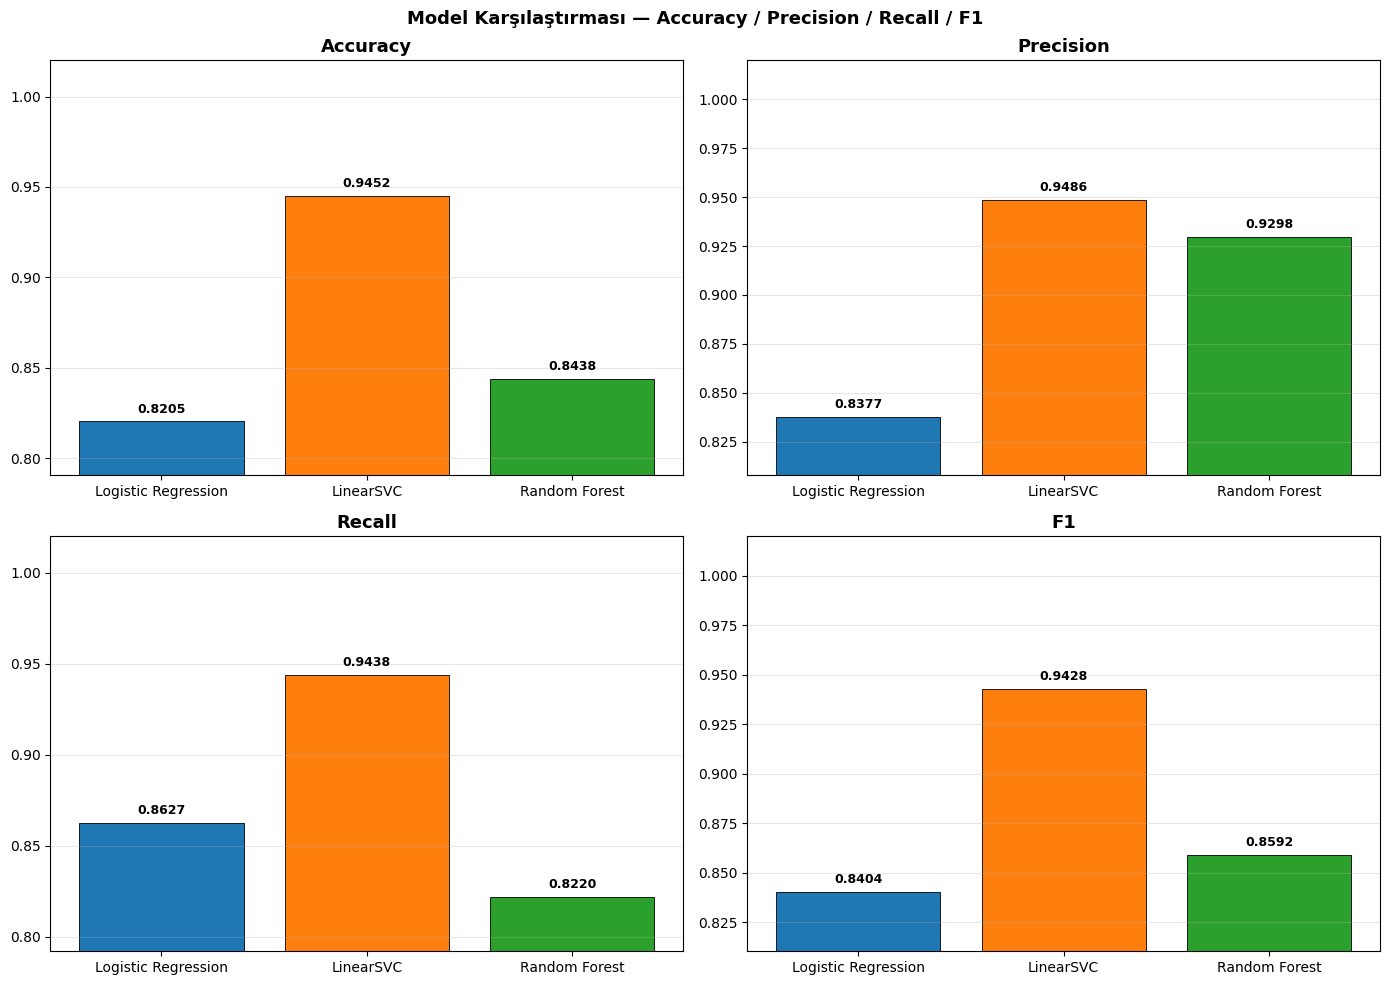

In [65]:
# ── Her modelin genel metrikleri ──────────────────────────────────────────────
satirlar = []
for isim in ['Logistic Regression', 'LinearSVC', 'Random Forest']:
 r = classification_report(y_test, sonuclar[isim], output_dict=True, zero_division=0)
 satirlar.append({
    'Model':     isim,
    'Accuracy':  r['accuracy'],
    'Precision': r['macro avg']['precision'],
    'Recall':    r['macro avg']['recall'],
    'F1':        r['macro avg']['f1-score'],
    })

df_met = pd.DataFrame(satirlar).set_index('Model')
print(df_met.round(4).to_string())

# ── Görsel ───────────────────────────────────────────────────────────────────
metriks  = ['Accuracy', 'Precision', 'Recall', 'F1']
renkler  = ['#1f77b4', '#ff7f0e', '#2ca02c']
modeller = df_met.index.tolist()

fig, axes = plt.subplots(2,2, figsize=(14, 10), sharey=False)
axes = axes.flatten()

for ax, metrik in zip(axes, metriks):
    degerler = df_met[metrik].values
    bars = ax.bar(modeller, degerler, color=renkler, edgecolor='black', linewidth=0.6)
    y_min = min(degerler) - 0.03
    ax.set_ylim(max(0, y_min), 1.02)
    ax.set_title(metrik, fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(modeller)))
    ax.set_xticklabels(modeller, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, degerler):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Karşılaştırması — Accuracy / Precision / Recall / F1',
                        fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/model_metrik_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

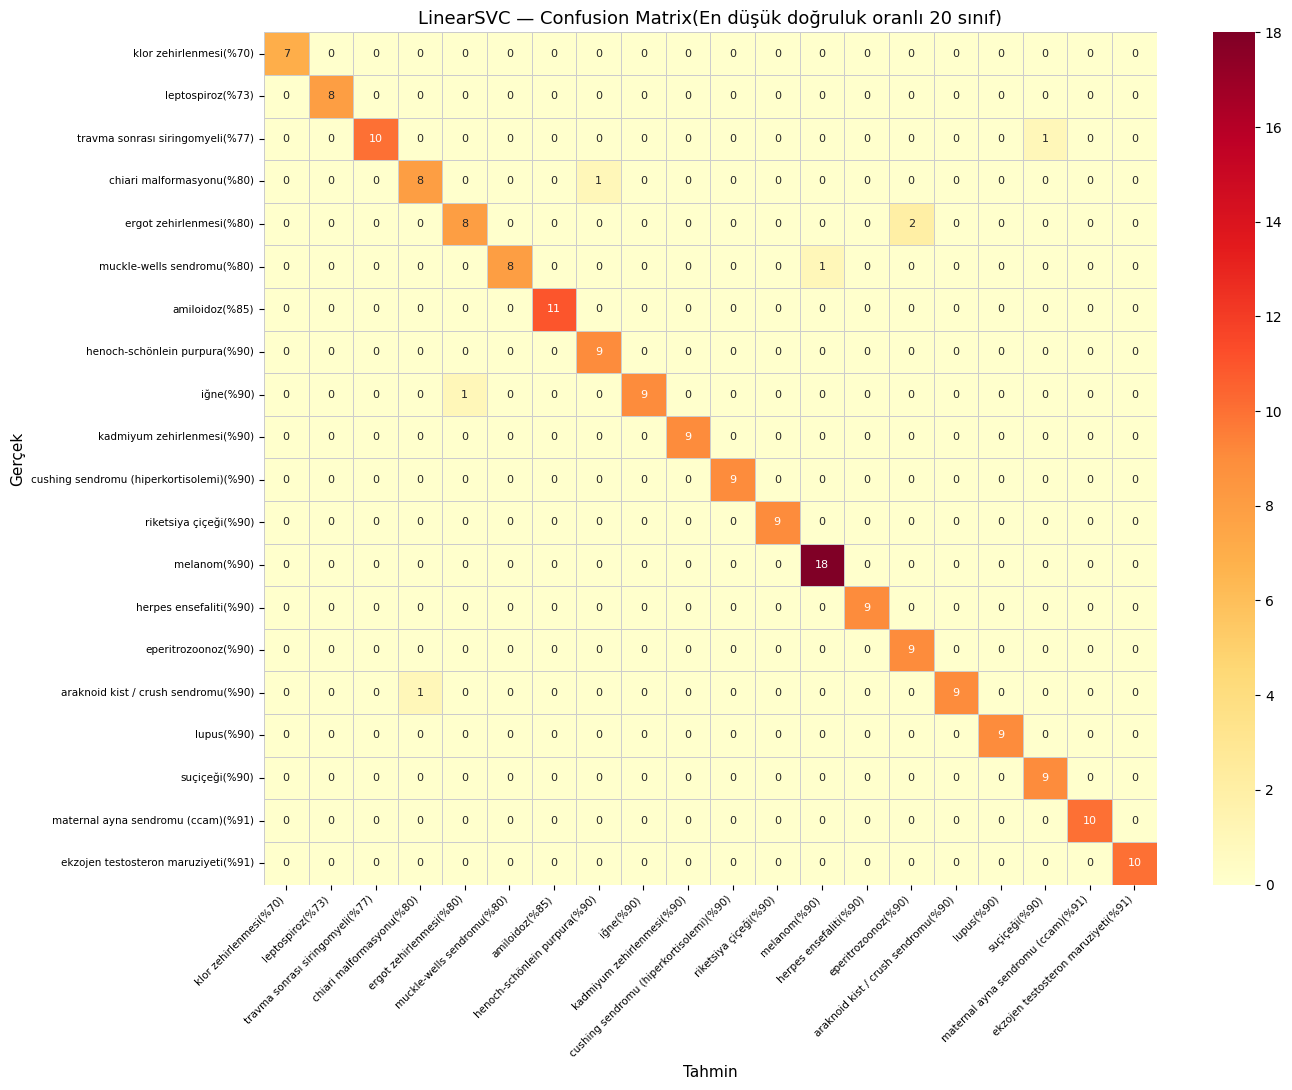

Sınıf                                           Doğruluk   Destek
-----------------------------------------------------------------
klor zehirlenmesi                             %    70.0       10
leptospiroz                                   %    72.7       11
travma sonrası siringomyeli                   %    76.9       13
chiari malformasyonu                          %    80.0       10
ergot zehirlenmesi                            %    80.0       10
muckle-wells sendromu                         %    80.0       10
amiloidoz                                     %    84.6       13
henoch-schönlein purpura                      %    90.0       10
iğne                                          %    90.0       10
kadmiyum zehirlenmesi                         %    90.0       10
cushing sendromu (hiperkortisolemi)           %    90.0       10
riketsiya çiçeği                              %    90.0       10
melanom                                       %    90.0       20
herpes ensefaliti      

In [69]:
import numpy as np
from sklearn.metrics import confusion_matrix

siniflar   = sorted(y.unique())
cm_svc     = confusion_matrix(y_test, sonuclar['LinearSVC'], labels=siniflar)

# Sınıf bazlı doğruluk oranı (diagonal / satır toplamı)
satir_toplam = cm_svc.sum(axis=1)
dogru_oran   = np.where(satir_toplam > 0, cm_svc.diagonal() / satir_toplam, 0)

# En düşük oranlı 20 sınıf
en_dusuk_idx = np.argsort(dogru_oran)[:20]
cm_filt      = cm_svc[np.ix_(en_dusuk_idx, en_dusuk_idx)]
sinif_filt   = [siniflar[i] for i in en_dusuk_idx]

# Etiket: sınıf adı + doğruluk oranı
etiketler = [f"{s}(%{dogru_oran[i]*100:.0f})" for s, i in zip(sinif_filt, en_dusuk_idx)]

plt.figure(figsize=(14, 11))
sns.heatmap(cm_filt, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=etiketler, yticklabels=etiketler,
            linewidths=0.4, linecolor='#cccccc',
            annot_kws={'size': 8})
plt.title('LinearSVC — Confusion Matrix(En düşük doğruluk oranlı 20 sınıf)', fontsize=13)
plt.xlabel('Tahmin', fontsize=11)
plt.ylabel('Gerçek', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=7.5)
plt.yticks(rotation=0, fontsize=7.5)
plt.tight_layout()
plt.savefig('images/svc_conf_dusuk20.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Sınıf':<45} {'Doğruluk':>10} {'Destek':>8}")
print('-' * 65)
for i in en_dusuk_idx:
    print(f"{siniflar[i]:<45} %{dogru_oran[i]*100:>8.1f} {satir_toplam[i]:>8}")